<a href="https://colab.research.google.com/github/mdzubayereashraf/Ostad-AI-Engineering-Course-Assignments/blob/main/Assignmen_No_12(Clustering_%26_Dimensionality_Reduction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clustering & Dimensionality Reduction**

##  **Loading important  libraries**

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# **Section A: K-Means Clustering & Elbow Method**
## Task 1: Load the Iris Dataset

In [3]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names =iris.feature_names
df = pd.DataFrame(X, columns= feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Explore the dataset

In [4]:
print("Shape of dataset:\n", X.shape)
print("Features:\n", feature_names)
print("Target classes:\n", iris.target_names)

Shape of dataset:
 (150, 4)
Features:
 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes:
 ['setosa' 'versicolor' 'virginica']


## Task 2: Standardize the Data

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

## Task 3: Elbow Method

In [11]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

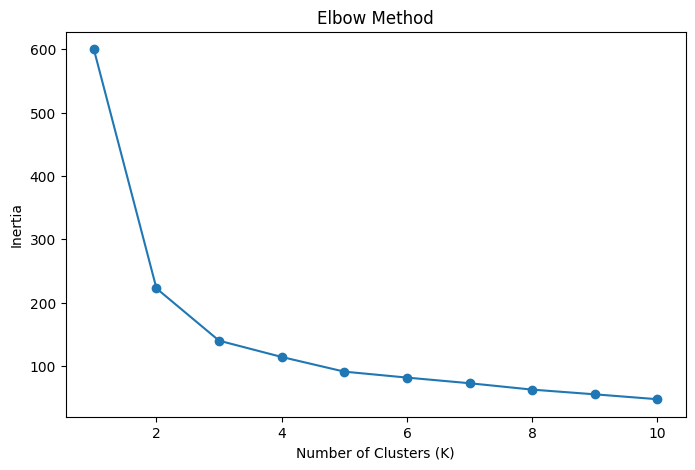

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

## Task 4: Apply K-Means

In [13]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print(kmeans_labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


## Task 5: Plot K-Means Clusters

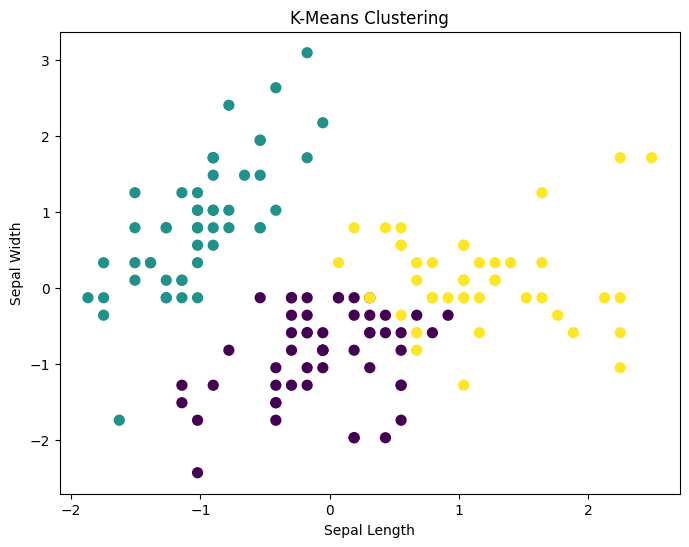

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=50
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering")

plt.show()

## **Interpretation**
K-Means divided the Iris dataset into three clusters.
The clusters represent groups of observations with similar
feature values. However, some overlap can be seen between
certain clusters when only the first two features are used.

# **Section B: Principal Component Analysis (PCA)**

## Task 1: Apply PCA

In [16]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (150, 4)
PCA shape: (150, 2)


## Task 2: Explained Variance Ratio

In [17]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.72962445 0.22850762]

Total explained variance:
0.9581320720000166


## Task 3: PCA Plot

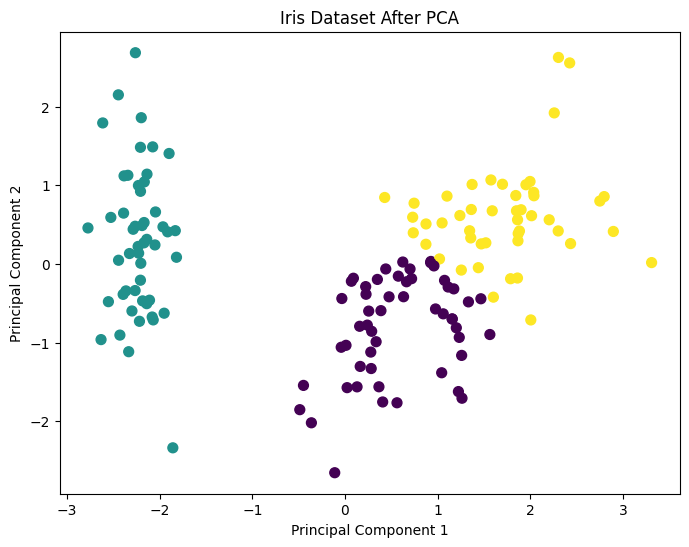

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset After PCA")

plt.show()

## **Interpretation**
PCA reduced the Iris dataset from four dimensions to two
dimensions while preserving a large amount of the original
variance. The two-dimensional plot makes the cluster structure
easier to visualize.

## Task 4: Compare K-Means on Original vs PCA Data

In [20]:
print("K-Means clustering on PCA data.")
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

pca_labels = kmeans_pca.fit_predict(X_pca)



K-Means clustering on PCA data.


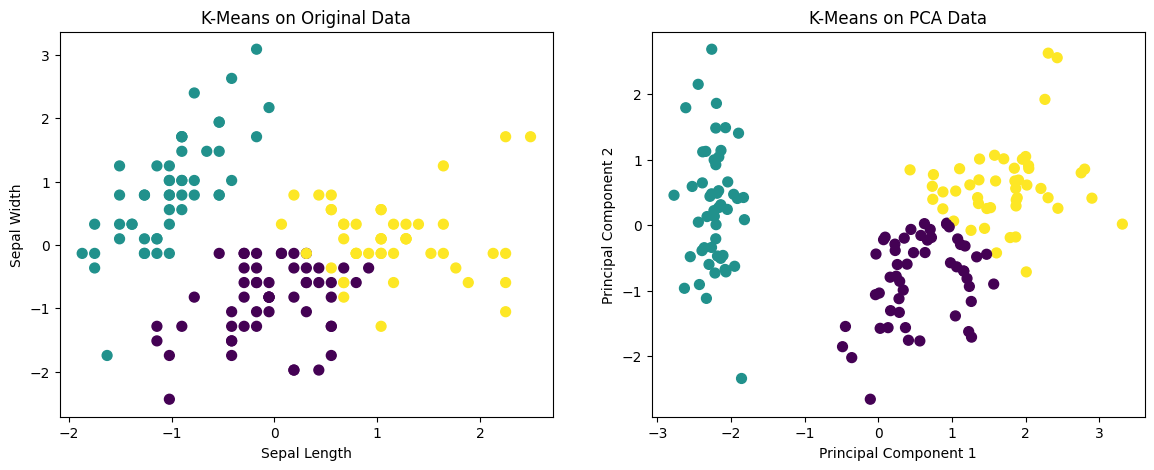

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data
axes[0].scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=50
)

axes[0].set_title("K-Means on Original Data")
axes[0].set_xlabel("Sepal Length")
axes[0].set_ylabel("Sepal Width")


# PCA data
axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=pca_labels,
    cmap='viridis',
    s=50
)

axes[1].set_title("K-Means on PCA Data")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

plt.show()

## **Interpretation**
K-Means produces similar groupings on the original standardized
data and the PCA-reduced data. PCA makes the clusters easier to
visualize because the four-dimensional dataset has been reduced
to two dimensions.

# **Section C: Hierarchical Clustering**